In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# Mount Google Drive if running on Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    # Use Google Drive for data storage
    DATA_PATH = '/content/drive/MyDrive/data'
    print("Google Drive mounted. Data path set to:", DATA_PATH)
except (ImportError, ValueError, Exception) as e:
    # Use local directory if not on Colab OR if drive mount fails
    DATA_PATH = './data'
    print("Drive mount failed or not running on standard Colab.")
    print(f"Error: {e}")
    print("Data path set to:", DATA_PATH)
    print("Note: If using VS Code with Colab, enable 'Colab: Mount Drive' in settings to support drive.mount().")

Drive mount failed or not running on standard Colab.
Error: mount failed
Data path set to: ./data
Note: If using VS Code with Colab, enable 'Colab: Mount Drive' in settings to support drive.mount().


In [2]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Hyperparameters
BATCH_SIZE = 128
EPOCHS = 30
LEARNING_RATE = 3e-4
PATCH_SIZE = 4
NUM_CLASSES = 10
IMAGE_SIZE = 32
CHANNELS = 3
EMBED_DIM = 256
NUM_HEADS = 8
DEPTH = 6
MLP_DIM = 512
DROP_RATE = 0.1

In [ ]:
# Data preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [5]:
train_dataset = datasets.CIFAR10(root=DATA_PATH, train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root=DATA_PATH, train=False, download=True, transform=transform)

In [18]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### ViT components

1. Class PatchEmbedding

In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        num_patches = (img_size // patch_size) ** 2
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, 1 + num_patches, embed_dim))

    def forward(self, x):
        B = x.size(0)
        x = self.proj(x)  # (B, E, H/P, W/P)

        # 2.3:
        x = x.flatten(2).transpose(1, 2)  #  -> (B, E, H/P, W/P) -> (B, E, N) -> (B, N, E)

        # flatten(2): The argument 2 tells Pytorch to start flattening from dimension
        # index 2 and merge all subsequent dimension into one. (B, E, H_p, W_p) -> (B, E, N)
        # N = H_p * W_p: represents the total number of patches (or tokens)

        # transpose(1, 2): swaps the dimensions from (B, E, N) to (B, N, E) because Pytorch's 
        # nn.MultiheadAttention (by default batch_first=True) expects the input in the format:
        # (Batch, Sequence Length, Feature Dimension (Embedding))

        # 2.4:
        cls_tokens = self.cls_token.expand(B, -1, -1)
        # cls_token is a learnable parameter initialized with shape (1, 1, E). It is the same
        # for every image. We couldnt initialize cls_token as (B, 1, E) because the Batch Size
        # B will change:
        # - During training (32)
        # - During validation (64)
        # - During inference (1)

        # x represents the patches for a whole batch of images. Its shape is (B, N, E)
        # We want to attach this class token to every single image in the batch, but we cannt
        # combine a tensor of size 1 with a tensor of size B (32).

        # .expand(B, -1, -1) creates a view of the tensor where the first dimension is repeated
        # B times (1, 1, E) --> (B, 1, E)
        # -1 means keep that dimension as it is

        # 2.5:
        x = torch.cat((cls_tokens, x), dim=1)
        # attaches the class token to the beginning of the sequences of image patches.
        # (B, 1, E) + (B, N, E) --> (B, N+1, E)

        # 2.6: Add positional information to the image patches through Broadcasting
        x = x + self.pos_embed
        # In Pytorch, if we try to perform an operation (like addition) on two tensors with
        # different shapes, the system automatically checks of it can "stretch" the smaller
        # tensor to match the larger one.
        
        return x

In [ ]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, drop_rate):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.dropout = nn.Dropout(drop_rate)

    def forward(self, x):
        x = self.dropout(F.gelu(self.fc1(x)))
        x = self.dropout(self.fc2(x))
        return x


In [ ]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, drop_rate):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=drop_rate, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_dim, drop_rate)

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

In [ ]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, num_classes, embed_dim, depth, num_heads, mlp_dim, drop_rate):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.encoder = nn.Sequential(*[
            TransformerEncoderLayer(embed_dim, num_heads, mlp_dim, drop_rate)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.encoder(x)
        x = self.norm(x)
        cls_token = x[:, 0]
        return self.head(cls_token)


In [11]:
# Instantiate model
model = VisionTransformer(
    IMAGE_SIZE, PATCH_SIZE, CHANNELS, NUM_CLASSES,
    EMBED_DIM, DEPTH, NUM_HEADS, MLP_DIM, DROP_RATE
).to(device)

In [ ]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


In [ ]:
# Training loop
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


In [14]:
# Evaluation loop
def evaluate(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()
    return correct / len(loader.dataset)



In [15]:
# Training
train_accuracies, test_accuracies = [], []
for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    test_acc = evaluate(model, test_loader)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")


Epoch 1/30, Train Loss: 1.7183, Train Acc: 0.3781, Test Acc: 0.4813
Epoch 2/30, Train Loss: 1.3791, Train Acc: 0.5071, Test Acc: 0.5353
Epoch 3/30, Train Loss: 1.2420, Train Acc: 0.5550, Test Acc: 0.5587
Epoch 4/30, Train Loss: 1.1339, Train Acc: 0.5936, Test Acc: 0.5805
Epoch 5/30, Train Loss: 1.0489, Train Acc: 0.6257, Test Acc: 0.6071
Epoch 6/30, Train Loss: 0.9732, Train Acc: 0.6528, Test Acc: 0.6092
Epoch 7/30, Train Loss: 0.8932, Train Acc: 0.6808, Test Acc: 0.6169
Epoch 8/30, Train Loss: 0.8292, Train Acc: 0.7017, Test Acc: 0.6274
Epoch 9/30, Train Loss: 0.7564, Train Acc: 0.7299, Test Acc: 0.6281
Epoch 10/30, Train Loss: 0.6855, Train Acc: 0.7541, Test Acc: 0.6271
Epoch 11/30, Train Loss: 0.6196, Train Acc: 0.7782, Test Acc: 0.6326
Epoch 12/30, Train Loss: 0.5557, Train Acc: 0.8000, Test Acc: 0.6321
Epoch 13/30, Train Loss: 0.4961, Train Acc: 0.8219, Test Acc: 0.6347
Epoch 14/30, Train Loss: 0.4408, Train Acc: 0.8428, Test Acc: 0.6303
Epoch 15/30, Train Loss: 0.3849, Train Acc:

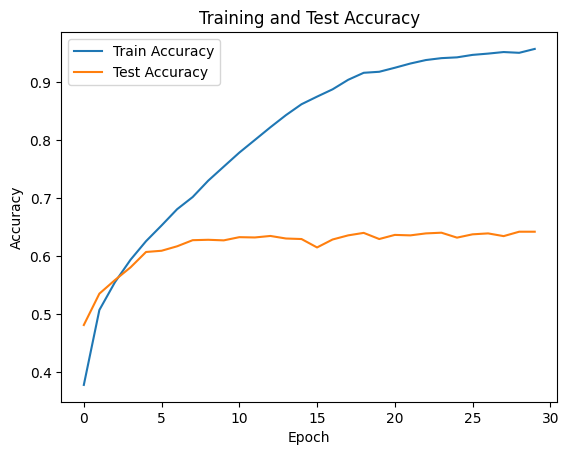

In [16]:
# Plot accuracy
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Test Accuracy')
plt.show()